# **Praktikum 3 Perbaikan Kualitas Citra**
#### Matakuliah: Computer Vision

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import cv2 

## **Mengolah Citra Malam**

In [2]:
img = cv2.imread('img/simpang.jpg')
if img is None:
    raise FileExistsError('simpang.jpg tidak ditemukan di folder ini')

# Memisahkan kanal RGB
b, g, r = cv2.split(img)
b_new = (b * 0.3).astype(np.uint8)
g_new = (g * 0.3).astype(np.uint8)
r_new = (r * 0.3).astype(np.uint8)

# Menaggabungkan kembali warna
img_night = cv2.merge([b_new, g_new, r_new])

# Konversi citra BGR ke RGB
rgb = cv2.cvtColor(img_night, cv2.COLOR_BGR2RGB)
# cv2.imwrite('img/simpang_malam.jpg', img_night)

Text(0.5, 1.0, 'Citra Simpang Malam')

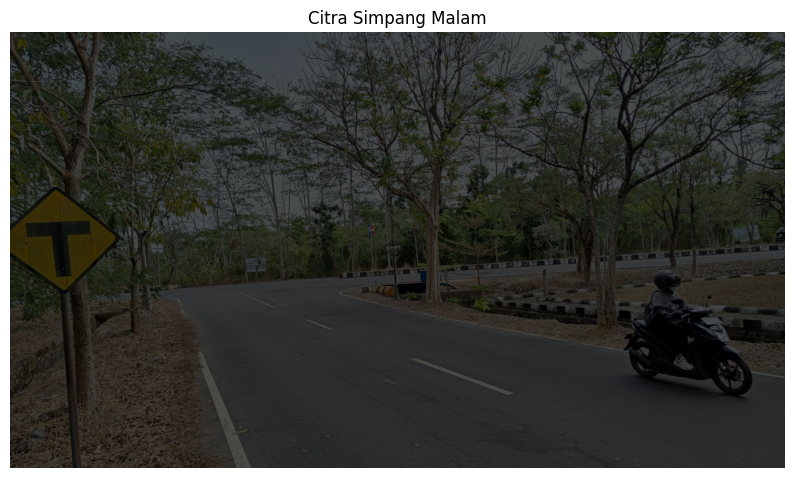

In [3]:
plt.figure(figsize=(10, 8))

plt.imshow(rgb, cmap='gray')
plt.axis('off')
plt.title("Citra Simpang Malam")

In [4]:
def tambah_derau_gaussian(citra, sigma=30):
    derau = np.random.normal(0, sigma, citra.shape).astype(np.float32)
    hasil = citra.astype(np.float32) + derau
    return np.clip(hasil, 0, 225).astype(np.uint8)

img_night_g = tambah_derau_gaussian(img_night)
rgb = cv2.cvtColor(img_night_g, cv2.COLOR_BGR2RGB)
cv2.imwrite('img/simpang_malam.jpg', img_night_g)

True

Text(0.5, 1.0, 'Citra Simpang Malam Derau Gaussian')

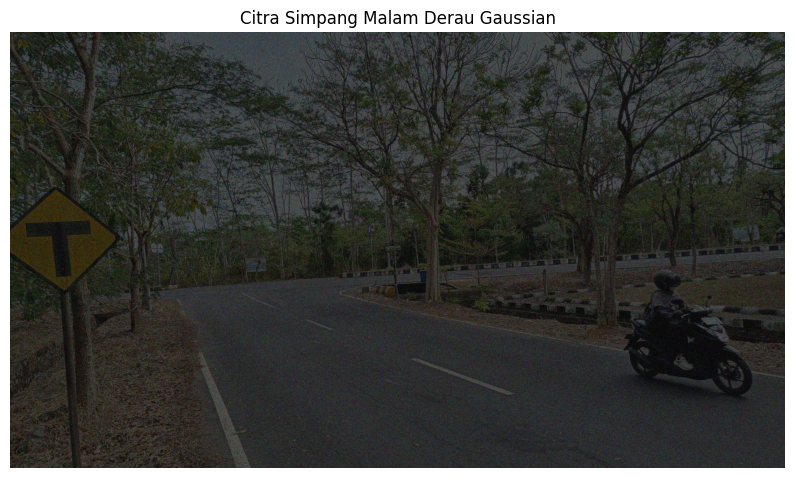

In [5]:
plt.figure(figsize=(10, 8))

plt.imshow(rgb, cmap='gray')
plt.axis('off')
plt.title("Citra Simpang Malam Derau Gaussian")

## **Mengolah Citra Biner**

In [6]:
# Konversi citra BGR ke Gray
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

thres, otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

Text(0.5, 1.0, 'Citra Simpang Biner')

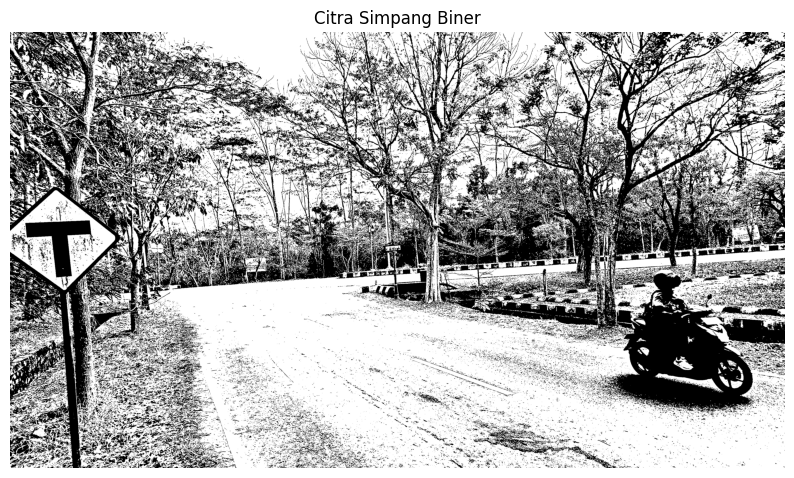

In [7]:
plt.figure(figsize=(10, 8))

plt.imshow(otsu, cmap='gray')
plt.axis('off')
plt.title('Citra Simpang Biner')

In [8]:
def tambah_derau_garam_merica(citra, jumlah=0.04):
    hasil = citra.copy()
    tinggi, lebar = citra.shape[:2]
    
    # jumlah piksel yang akan diubah untuk masing-masing derau
    n = int(jumlah * tinggi * lebar / 2)
    
    # 2. Tambahkan GARAM (Bintik Putih = 255)
    ys_salt = np.random.randint(0, tinggi, n)
    xs_salt = np.random.randint(0, lebar, n)
    hasil[ys_salt, xs_salt] = 255  # Membuat bintik putih di atas latar abu-abu/hitam
    
    # 3. Tambahkan MERICA (Bintik Hitam = 0)
    ys_pepper = np.random.randint(0, tinggi, n)
    xs_pepper = np.random.randint(0, lebar, n)
    hasil[ys_pepper, xs_pepper] = 0  # Membuat bintik hitam di atas latar abu-abu/putih
    
    return hasil

img_otsu_sp = tambah_derau_garam_merica(otsu)
cv2.imwrite('img/simpang_biner.jpg', img_otsu_sp)           

True

## **Memuat Citra dan Menghitung Histogram**

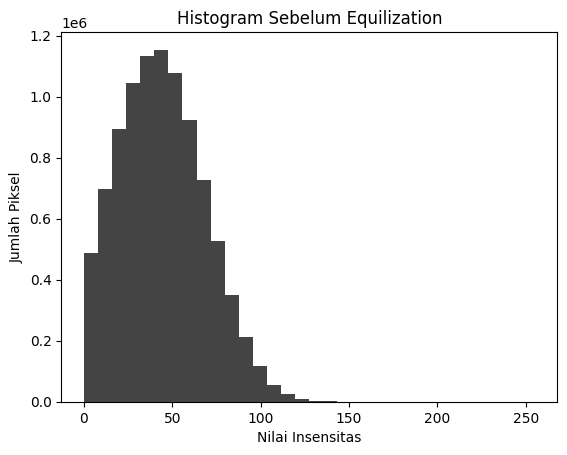

Rata-rata : 44.09144920772977
Simpangan : 23.98638874477487


In [9]:
citra_malam = cv2.imread('img/simpang_malam.jpg')
gray1 = cv2.cvtColor(citra_malam, cv2.COLOR_BGR2GRAY)

plt.hist(gray1.ravel(), bins=32, range=(0,255), color='#444')
plt.xlabel("Nilai Insensitas")
plt.ylabel("Jumlah Piksel")
plt.title('Histogram Sebelum Equilization')
plt.savefig('img/hist_sebelum.png') # hapus untuk menyimpan ke folder 
plt.show()

print('Rata-rata :', gray1.mean())
print('Simpangan :', gray1.std())

## **Menerapkan Histogram Equalization Global**

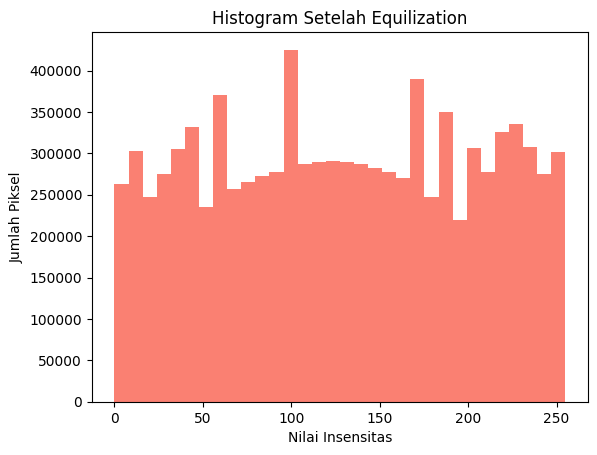

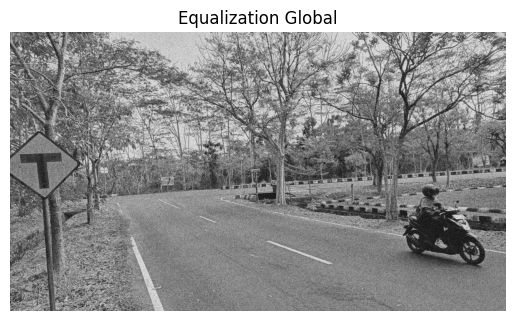

Rata-rata setelah equalize : 128.84970495435925
Simpangan setelah equalize : 73.53371710328304


In [10]:
eq = cv2.equalizeHist(gray1)
cv2.imwrite('hasil_equalize.jpg', eq)

plt.hist(eq.ravel(), bins=32, range=(0,255), color='salmon')
plt.xlabel("Nilai Insensitas")
plt.ylabel("Jumlah Piksel")
plt.title('Histogram Setelah Equilization')
# plt.savefig('img/hist_sesudah.png') # hapus untuk menyimpan ke folder 
plt.show()

plt.imshow(eq, cmap='gray')
plt.axis('off')
plt.title('Equalization Global')
plt.show()


print('Rata-rata setelah equalize :', eq.mean())
print('Simpangan setelah equalize :', eq.std())

## **Menerapkan CLAHE**

Rata-rata CLAHE : 95.94877900017633
Simpangan CLAHE : 51.87205143270366


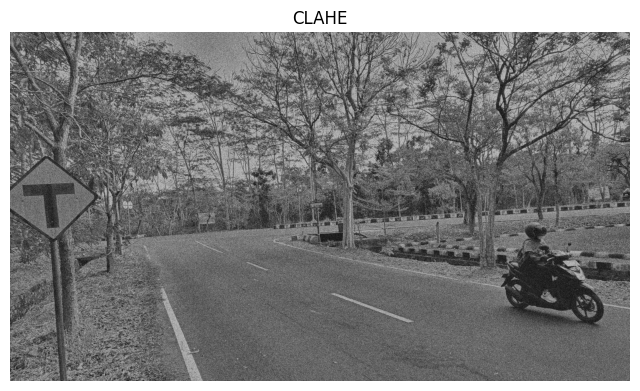

In [11]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
hasil_clahe = clahe.apply(gray1)

plt.figure(figsize=(8, 8))
plt.imshow(hasil_clahe, cmap='gray')
plt.axis('off')
plt.title('CLAHE')

# cv2.imwrite('img/hasil_clahe.jpg', hasil_clahe)
print('Rata-rata CLAHE :', hasil_clahe.mean())
print('Simpangan CLAHE :', hasil_clahe.std())

Text(0.5, 1.0, 'CLAHE (clip 2.0, title 8x8)')

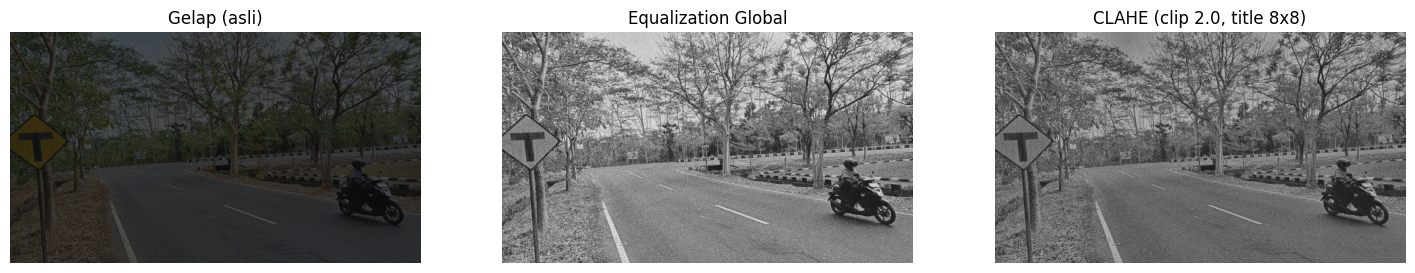

In [12]:
plt.figure(figsize=(18,9))

plt.subplot(1, 3, 1)
plt.imshow(rgb, cmap='gray')
plt.axis('off')
plt.title('Gelap (asli)')

plt.subplot(1, 3, 2)
plt.imshow(eq, cmap='gray')
plt.axis('off')
plt.title('Equalization Global')

plt.subplot(1, 3, 3)
plt.imshow(hasil_clahe, cmap='gray')
plt.axis('off')
plt.title('CLAHE (clip 2.0, title 8x8)')

## **Menyiapkan  Citra Biner untuk Morfologi**

In [13]:
biner = cv2.imread('img/citra_simpang_biner.jpg',  cv2.IMREAD_GRAYSCALE)
_, biner = cv2.threshold(biner, 127, 255, cv2.THRESH_BINARY)

def hitung_komponen(citra):
    n, _ = cv2.connectedComponents(citra)
    return n - 1

print('Jumlah komponen pada citra biner + derau : ', hitung_komponen(biner))

Jumlah komponen pada citra biner + derau :  24512


## **Menerapkan Erosi, Dilasi, Opening, dan Closing**

In [14]:
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))

erosi = cv2.erode(biner, kernel, iterations=1)
dilasi = cv2.dilate(biner, kernel, iterations=1)
opening = cv2.morphologyEx(biner, cv2.MORPH_OPEN, kernel)
closing = cv2.morphologyEx(biner, cv2.MORPH_CLOSE, kernel)

for nama, hasil in [('erosi', erosi), ('dilasi', dilasi), ('opening', opening), ('closing', closing)]:
    cv2.imwrite(f'hasil_{nama}.jpg', hasil)
    print(nama, '-> jumlah komponen:', hitung_komponen(hasil))

erosi -> jumlah komponen: 27931
dilasi -> jumlah komponen: 3957
opening -> jumlah komponen: 15456
closing -> jumlah komponen: 8449


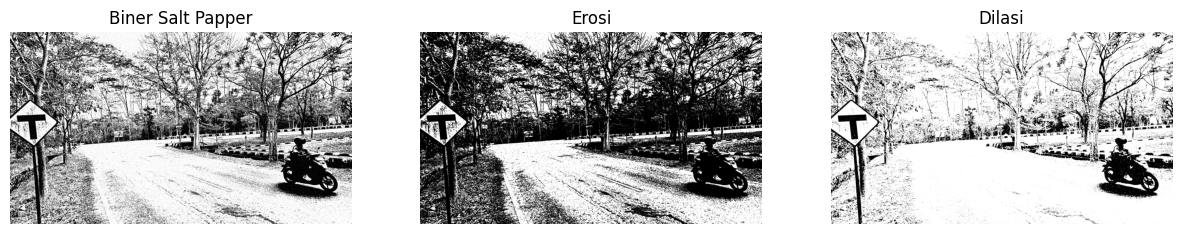

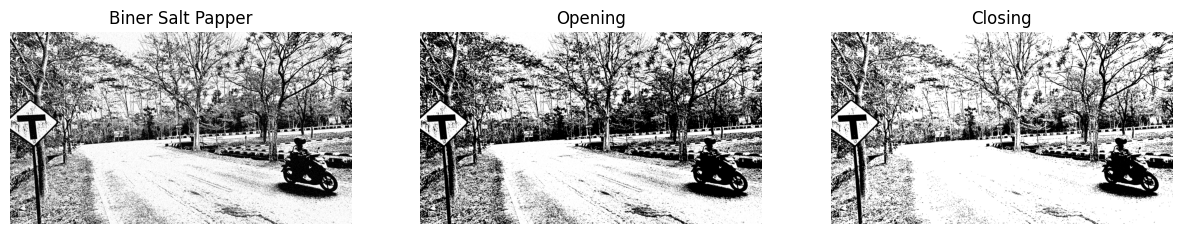

In [25]:
plt.figure(figsize=(15, 10))
plt.subplot(1, 3, 1)
plt.imshow(img_otsu_sp, cmap='gray')
plt.axis('off')
plt.title('Biner Salt Papper')

plt.subplot(1, 3, 2)
plt.imshow(erosi, cmap='gray')
plt.axis('off')
plt.title('Erosi')

plt.subplot(1, 3, 3)
plt.imshow(dilasi, cmap='gray')
plt.axis('off')
plt.title('Dilasi')
plt.show()

plt.figure(figsize=(15, 10))
plt.subplot(2, 3, 1)
plt.imshow(img_otsu_sp, cmap='gray')
plt.axis('off')
plt.title('Biner Salt Papper')

plt.subplot(2, 3, 2)
plt.imshow(opening, cmap='gray')
plt.axis('off')
plt.title('Opening')

plt.subplot(2, 3, 3)
plt.imshow(closing, cmap='gray')
plt.axis('off')
plt.title('Closing')
plt.show()